In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, TheilSenRegressor, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных

In [17]:
df = pd.read_excel('Проект_ML.xlsx', sheet_name='Проект_ML')

for col in ['тип чашки', 'наличие крышки', 'объём налитого', 'температура в комнате']:
    df[col] = df[col].astype(str).str.strip()

print("\nНазвания колонок:")
print(df.columns.tolist())

print("\nПервые 5 строк:")
print(df.head())



Названия колонок:
['тип чашки', 'наличие крышки', 'объём налитого', 'температура в комнате', 'время эксперимента', 'итоговая температура']

Первые 5 строк:
  тип чашки наличие крышки объём налитого температура в комнате  \
0  керамика             да       половина               холодно   
1    стекло            нет         полная               холодно   
2    стекло            нет         полная               холодно   
3    стекло            нет         полная               холодно   
4    стекло            нет       половина             нормально   

  время эксперимента  итоговая температура  
0        7 мин 1 сек                  64.9  
1       5 мин 28 сек                  68.8  
2       13 мин 3 сек                  53.5  
3      17 мин 30 сек                  47.8  
4       3 мин 14 сек                  73.6  


# Преобразование времени и категориальных признаков

In [19]:
def time_to_minutes(time_str):
    if pd.isna(time_str):
        return np.nan
    time_str = str(time_str)
    if 'мин' in time_str:
        parts = time_str.replace('сек', '').split('мин')
        minutes = int(parts[0].strip())
        seconds = int(parts[1].strip()) if len(parts) > 1 and parts[1].strip() else 0
        return minutes + seconds / 60
    return float(time_str)

df['minutes'] = df['время эксперимента'].apply(time_to_minutes)

df['lid_binary'] = df['наличие крышки'].map({'да': 1, 'нет': 0})

df = pd.get_dummies(df, columns=['тип чашки', 'объём налитого', 'температура в комнате'], drop_first=True)

# Подготовка признаков

In [20]:
target = 'итоговая температура'

feature_cols = ['minutes', 'lid_binary'] + \
               [c for c in df.columns if c.startswith('тип чашки_')] + \
               [c for c in df.columns if c.startswith('объём налитого_')] + \
               [c for c in df.columns if c.startswith('температура в комнате_')]

X = df[feature_cols]
y = df[target]

print(f"\nРазмер матрицы признаков: {X.shape}")
print(f"Признаки: {feature_cols}")


Размер матрицы признаков: (100, 7)
Признаки: ['minutes', 'lid_binary', 'тип чашки_стекло', 'объём налитого_половина', 'объём налитого_четверть', 'температура в комнате_нормально', 'температура в комнате_холодно']


# Проверка на мультиколлинеарность (VIF)

In [21]:
X_vif = X.astype(float)

X_vif = X_vif.assign(const=1)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                    for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['feature'] != 'const']

vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n VIF (Variance Inflation Factor):")
for _, row in vif_data.iterrows():
    vif_val = row['VIF']
    if np.isinf(vif_val):
        print(f"   {row['feature']}: inf (идеальная коллинеарность из-за one-hot encoding)")
    elif vif_val > 10:
        print(f"   {row['feature']}: {vif_val:.2f} (высокая мультиколлинеарность)")
    elif vif_val > 5:
        print(f"   {row['feature']}: {vif_val:.2f} (умеренная корреляция)")
    else:
        print(f"   {row['feature']}: {vif_val:.2f} (низкая корреляция)")

high_vif = vif_data[vif_data['VIF'] >= 5]
if len(high_vif) > 0 and not np.isinf(high_vif['VIF'].values[0]):
    print(f"\n Признаки с VIF >= 5 (потенциальная проблема):")
    for _, row in high_vif.iterrows():
        if not np.isinf(row['VIF']):
            print(f"   - {row['feature']}: VIF = {row['VIF']:.2f}")
else:
    print("\n Все признаки имеют VIF < 5 — мультиколлинеарность отсутствует")


 VIF (Variance Inflation Factor):
   объём налитого_четверть: 1.35 (низкая корреляция)
   объём налитого_половина: 1.34 (низкая корреляция)
   температура в комнате_холодно: 1.34 (низкая корреляция)
   температура в комнате_нормально: 1.33 (низкая корреляция)
   lid_binary: 1.01 (низкая корреляция)
   minutes: 1.01 (низкая корреляция)
   тип чашки_стекло: 1.00 (низкая корреляция)

 Все признаки имеют VIF < 5 — мультиколлинеарность отсутствует


# Поиск выбросов по методу IQR

In [22]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = y[(y < lower_bound) | (y > upper_bound)]

print(f"\n Статистика для целевой переменной (температура):")
print(f"   Q1 (25-й процентиль): {Q1:.1f}°C")
print(f"   Q3 (75-й процентиль): {Q3:.1f}°C")
print(f"   IQR (межквартильный размах): {IQR:.1f}°C")
print(f"   Нижняя граница: {lower_bound:.1f}°C")
print(f"   Верхняя граница: {upper_bound:.1f}°C")
print(f"\n Количество выбросов по IQR: {len(outliers_iqr)} из {len(y)} ({100 * len(outliers_iqr) / len(y):.1f}%)")



 Статистика для целевой переменной (температура):
   Q1 (25-й процентиль): 54.8°C
   Q3 (75-й процентиль): 73.4°C
   IQR (межквартильный размах): 18.5°C
   Нижняя граница: 27.0°C
   Верхняя граница: 101.2°C

 Количество выбросов по IQR: 0 из 100 (0.0%)


# Построение ящиков с усами

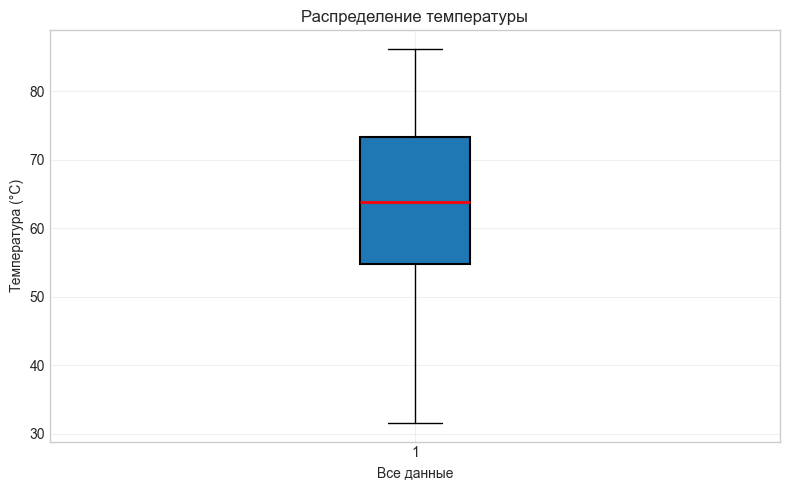

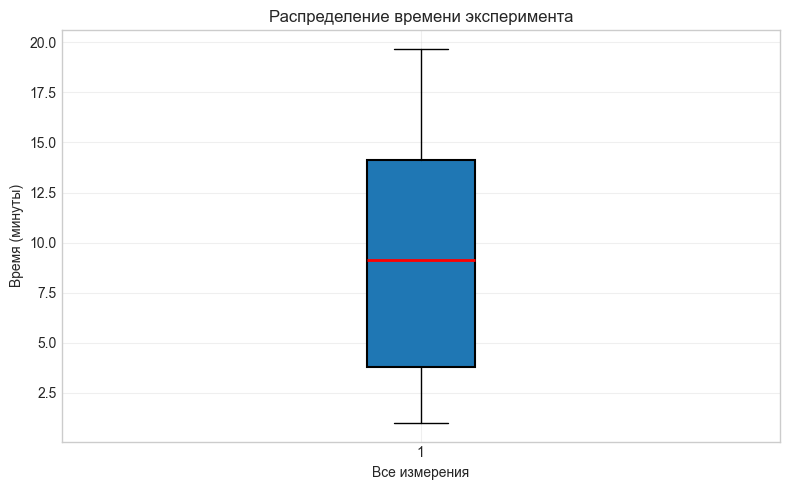


 Статистика времени эксперимента:
   Минимум: 1.0 мин
   Медиана: 9.1 мин
   Максимум: 19.7 мин
   Среднее: 9.3 мин


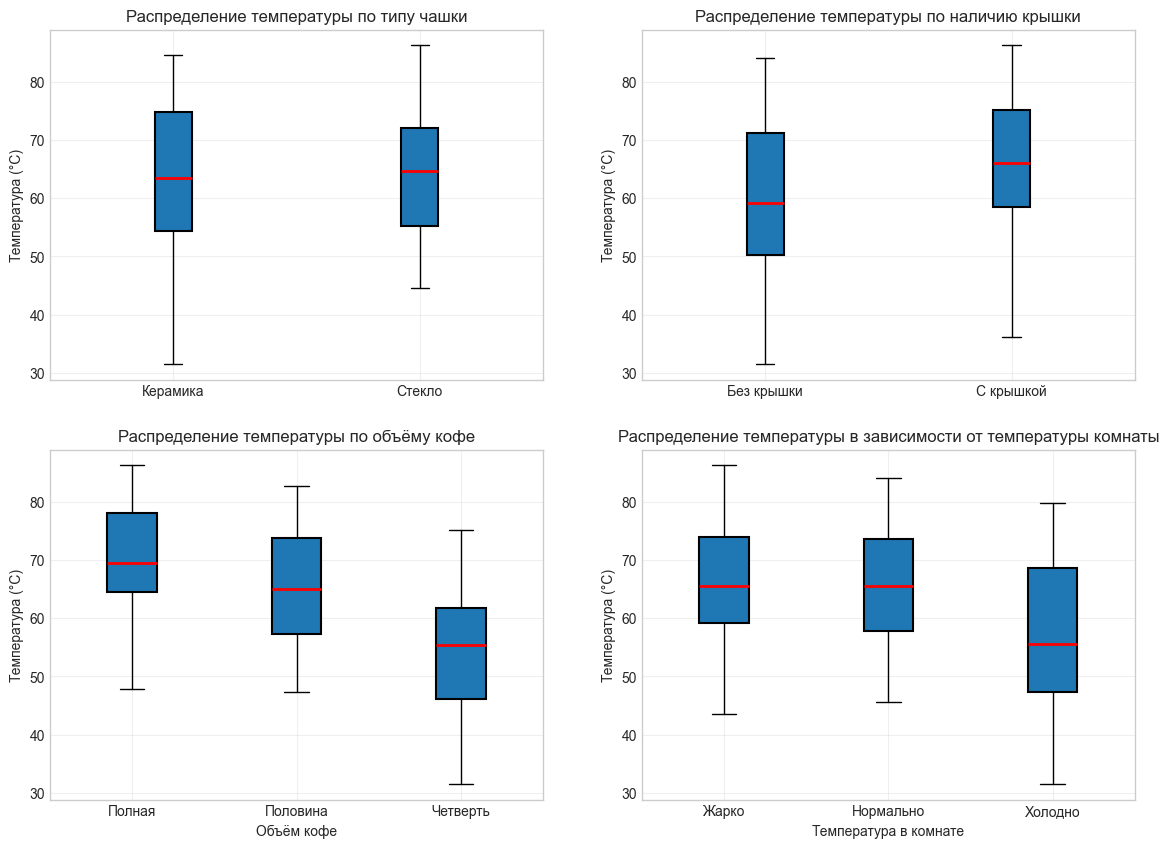

In [23]:
plt.figure(figsize=(8, 5))
plt.boxplot(y, patch_artist=True,
            boxprops=dict(linewidth=1.5), 
            medianprops=dict(color='red', linewidth=2))
plt.ylabel('Температура (°C)')
plt.xlabel('Все данные')
plt.title('Распределение температуры')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.boxplot(df['minutes'], patch_artist=True,
            boxprops=dict(linewidth=1.5), 
            medianprops=dict(color='red', linewidth=2))
plt.ylabel('Время (минуты)')
plt.xlabel('Все измерения')
plt.title('Распределение времени эксперимента')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Статистика времени эксперимента:")
print(f"   Минимум: {df['minutes'].min():.1f} мин")
print(f"   Медиана: {df['minutes'].median():.1f} мин")
print(f"   Максимум: {df['minutes'].max():.1f} мин")
print(f"   Среднее: {df['minutes'].mean():.1f} мин")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Тип чашки
cup_data = [
    df[df['тип чашки_стекло'] == 0][target],
    df[df['тип чашки_стекло'] == 1][target]
]
axes[0, 0].boxplot(cup_data, labels=['Керамика', 'Стекло'], patch_artist=True,
                   boxprops=dict(linewidth=1.5), medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].set_title('Распределение температуры по типу чашки')
axes[0, 0].grid(True, alpha=0.3)

# 2. Наличие крышки
lid_data = [df[df['lid_binary'] == 0][target], df[df['lid_binary'] == 1][target]]
axes[0, 1].boxplot(lid_data, labels=['Без крышки', 'С крышкой'], patch_artist=True,
                   boxprops=dict(linewidth=1.5), medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Температура (°C)')
axes[0, 1].set_title('Распределение температуры по наличию крышки')
axes[0, 1].grid(True, alpha=0.3)

# 3. Объём
mask_full = (df['объём налитого_половина'] == 0) & (df['объём налитого_четверть'] == 0)
volume_data = [
    df[mask_full][target],
    df[df['объём налитого_половина'] == 1][target],
    df[df['объём налитого_четверть'] == 1][target]
]
axes[1, 0].boxplot(volume_data, labels=['Полная', 'Половина', 'Четверть'], patch_artist=True,
                   boxprops=dict(linewidth=1.5), medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Температура (°C)')
axes[1, 0].set_xlabel('Объём кофе')
axes[1, 0].set_title('Распределение температуры по объёму кофе')
axes[1, 0].grid(True, alpha=0.3)

# 4. Температура комнаты
mask_hot = (df['температура в комнате_нормально'] == 0) & (df['температура в комнате_холодно'] == 0)
temp_data = [
    df[mask_hot][target],
    df[df['температура в комнате_нормально'] == 1][target],
    df[df['температура в комнате_холодно'] == 1][target]
]
axes[1, 1].boxplot(temp_data, labels=['Жарко', 'Нормально', 'Холодно'], patch_artist=True,
                   boxprops=dict(linewidth=1.5), medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Температура (°C)')
axes[1, 1].set_xlabel('Температура в комнате')
axes[1, 1].set_title('Распределение температуры в зависимости от температуры комнаты')
axes[1, 1].grid(True, alpha=0.3)


# k-fold кросс-валидация


 Результаты k-fold кросс-валидации (k=5):
            Model       R²      MAE
Linear Regression 0.867447 3.220678
            Ridge 0.864430 3.299880
        Theil-Sen 0.858182 3.469586
            Lasso 0.719916 5.032651


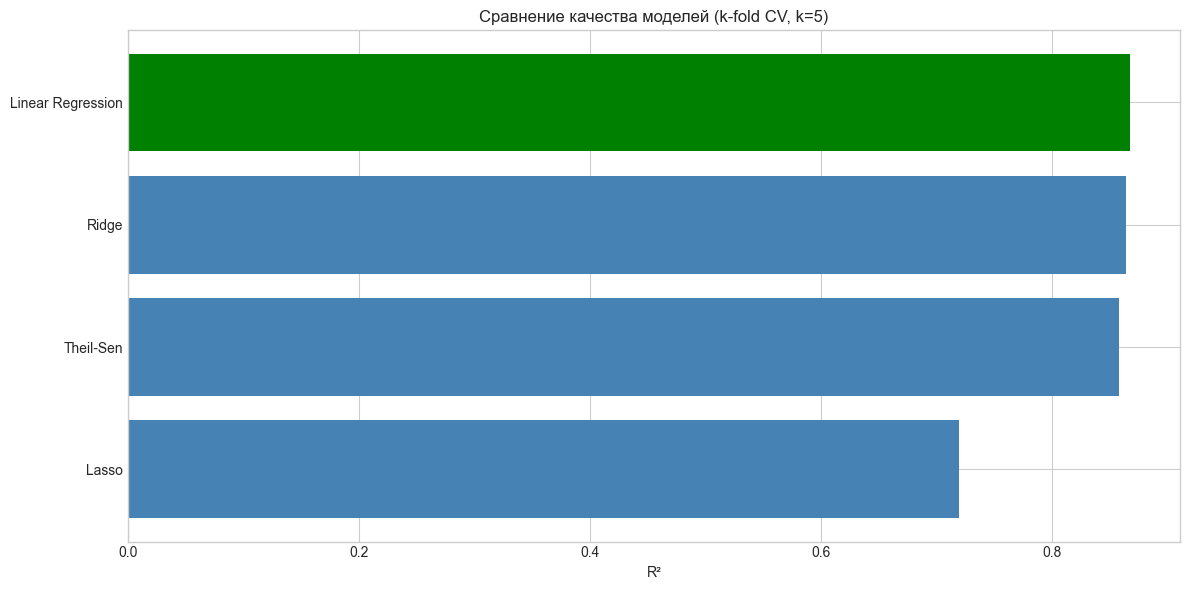

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Theil-Sen': TheilSenRegressor(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=10000)
}

cv_results = []

for name, model in models_cv.items():
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    
    cv_results.append({
        'Model': name,
        'R²': r2_scores.mean(),
        'MAE': mae_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values('R²', ascending=False)

print("\n Результаты k-fold кросс-валидации (k=5):")
print(cv_results_df.to_string(index=False))

plt.figure(figsize=(12, 6))
models_names = cv_results_df['Model'].tolist()
r2_values = cv_results_df['R²'].tolist()

colors = ['green' if i == 0 else 'steelblue' for i in range(len(models_names))]
plt.barh(models_names, r2_values, color=colors)
plt.xlabel('R²')
plt.title('Сравнение качества моделей (k-fold CV, k=5)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# График сравнения всех моделей (Предсказание vs Реальность)

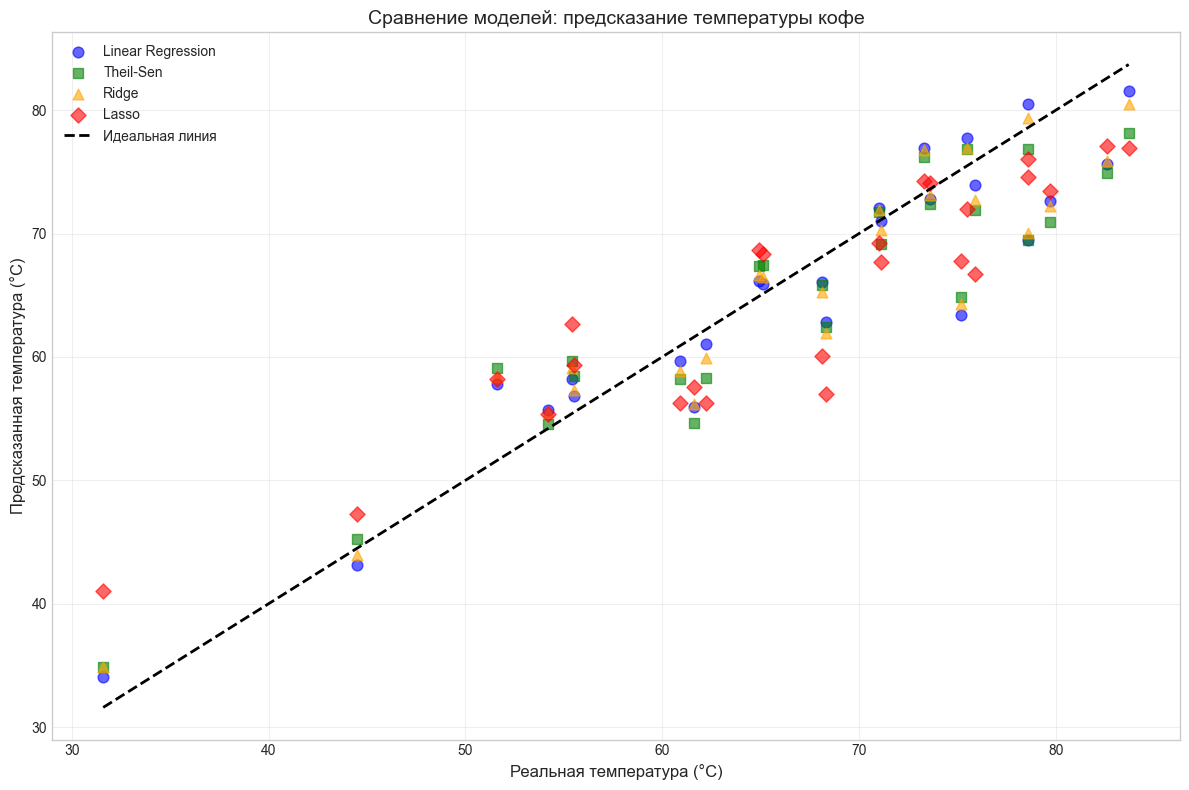

In [25]:
X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(X, y, test_size=0.25, random_state=42)

models_plot = {
    'Linear Regression': LinearRegression(),
    'Theil-Sen': TheilSenRegressor(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=10000)
}

predictions = {}
for name, model in models_plot.items():
    model.fit(X_train_plot, y_train_plot)
    predictions[name] = model.predict(X_test_plot)

colors_markers = {
    'Linear Regression': ('blue', 'o'),
    'Theil-Sen': ('green', 's'),
    'Ridge': ('orange', '^'),
    'Lasso': ('red', 'D')
}

plt.figure(figsize=(12, 8))

for name, y_pred in predictions.items():
    color, marker = colors_markers[name]
    plt.scatter(y_test_plot, y_pred, alpha=0.6, color=color, marker=marker, label=name, s=60)

min_val = min(y_test_plot.min(), min(pred.min() for pred in predictions.values()))
max_val = max(y_test_plot.max(), max(pred.max() for pred in predictions.values()))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Идеальная линия')

plt.xlabel('Реальная температура (°C)', fontsize=12)
plt.ylabel('Предсказанная температура (°C)', fontsize=12)
plt.title('Сравнение моделей: предсказание температуры кофе', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Калибровка предсказаний (Isotonic Regression)

In [26]:
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(X, y, test_size=0.25, random_state=42)

X_train_cal_val, X_cal, y_train_cal_val, y_cal = train_test_split(
    X_train_cal, y_train_cal, test_size=0.3, random_state=42
)

base_model = LinearRegression()
base_model.fit(X_train_cal_val, y_train_cal_val)

y_cal_pred = base_model.predict(X_cal)

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(y_cal_pred, y_cal)

y_pred_raw = base_model.predict(X_test_cal)
y_pred_calibrated = calibrator.predict(y_pred_raw)

r2_raw = r2_score(y_test_cal, y_pred_raw)
r2_cal = r2_score(y_test_cal, y_pred_calibrated)
mae_raw = mean_absolute_error(y_test_cal, y_pred_raw)
mae_cal = mean_absolute_error(y_test_cal, y_pred_calibrated)

print(f"\n Линейная регрессия (базовая):")
print(f"   R² = {r2_raw:.4f}, MAE = {mae_raw:.2f}°C")
print(f"\n Линейная регрессия (калиброванная):")
print(f"   R² = {r2_cal:.4f}, MAE = {mae_cal:.2f}°C")

if r2_cal > r2_raw:
    print(f"    Калибровка улучшила R² на {r2_cal - r2_raw:.4f}")
else:
    print(f"    Калибровка не дала улучшения (модель уже хорошо откалибрована)")


 Линейная регрессия (базовая):
   R² = 0.8524, MAE = 3.51°C

 Линейная регрессия (калиброванная):
   R² = 0.8566, MAE = 3.80°C
    Калибровка улучшила R² на 0.0042


**Сравнение до и после калибровки**

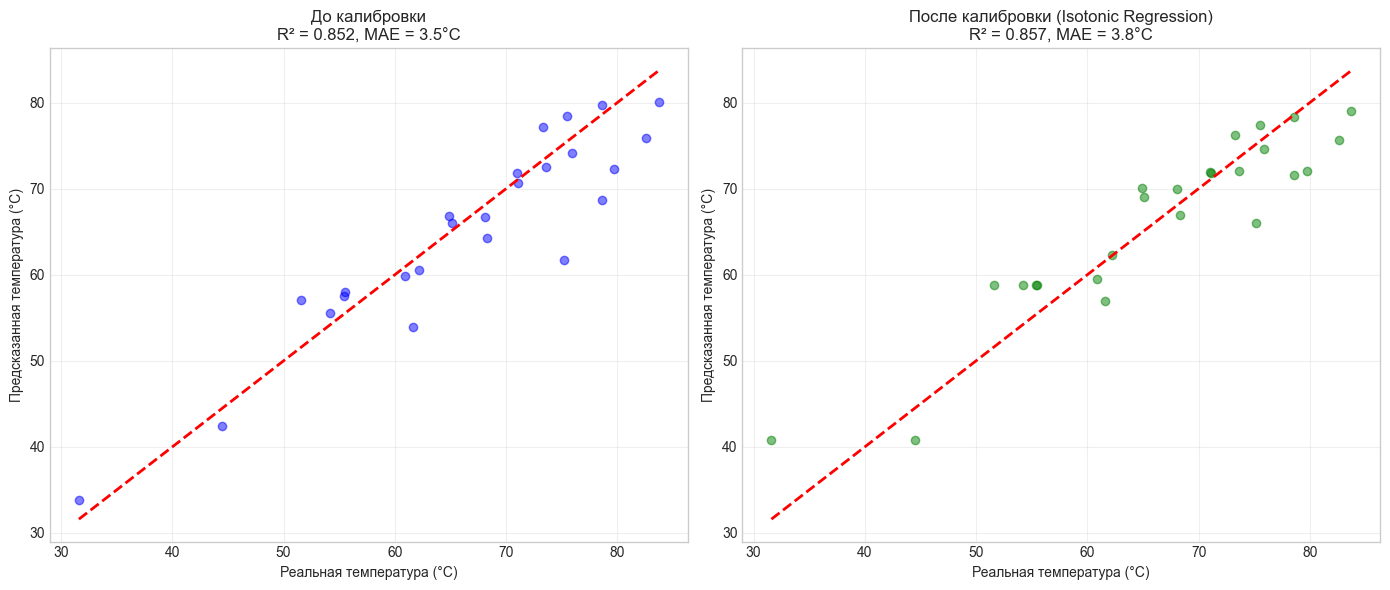

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_cal, y_pred_raw, alpha=0.5, color='blue')
axes[0].plot([y_test_cal.min(), y_test_cal.max()], [y_test_cal.min(), y_test_cal.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальная температура (°C)')
axes[0].set_ylabel('Предсказанная температура (°C)')
axes[0].set_title(f'До калибровки\nR² = {r2_raw:.3f}, MAE = {mae_raw:.1f}°C')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_cal, y_pred_calibrated, alpha=0.5, color='green')
axes[1].plot([y_test_cal.min(), y_test_cal.max()], [y_test_cal.min(), y_test_cal.max()], 'r--', lw=2)
axes[1].set_xlabel('Реальная температура (°C)')
axes[1].set_ylabel('Предсказанная температура (°C)')
axes[1].set_title(f'После калибровки (Isotonic Regression)\nR² = {r2_cal:.3f}, MAE = {mae_cal:.1f}°C')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Диагностика остатков (Лучшая модель из CV)

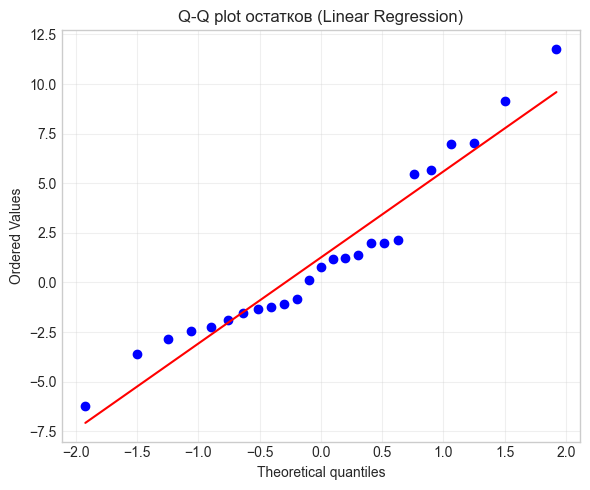


 Тест Шапиро-Уилка (Linear Regression):
   Statistic: 0.9386, p-value: 0.1378
    Остатки распределены нормально


In [28]:
best_model_name = cv_results_df.iloc[0]['Model']
best_reg_model = models_cv[best_model_name]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.25, random_state=42)
best_reg_model.fit(X_train_reg, y_train_reg)
y_pred_best = best_reg_model.predict(X_test_reg)
residuals = y_test_reg - y_pred_best

fig, axes = plt.subplots(1, 1, figsize=(6, 5))

stats.probplot(residuals, dist="norm", plot=axes)
axes.set_title(f'Q-Q plot остатков ({best_model_name})')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n Тест Шапиро-Уилка ({best_model_name}):")
print(f"   Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("    Остатки распределены нормально")
else:
    print("    Остатки НЕ распределены нормально")

# Важность признаков (Permutation importance)

                        Feature  Importance      Std
                        minutes    0.923427 0.128046
        объём налитого_четверть    0.594515 0.118762
  температура в комнате_холодно    0.132633 0.046839
        объём налитого_половина    0.072658 0.025110
                     lid_binary    0.043714 0.021212
температура в комнате_нормально    0.006498 0.005172
               тип чашки_стекло    0.000637 0.000835


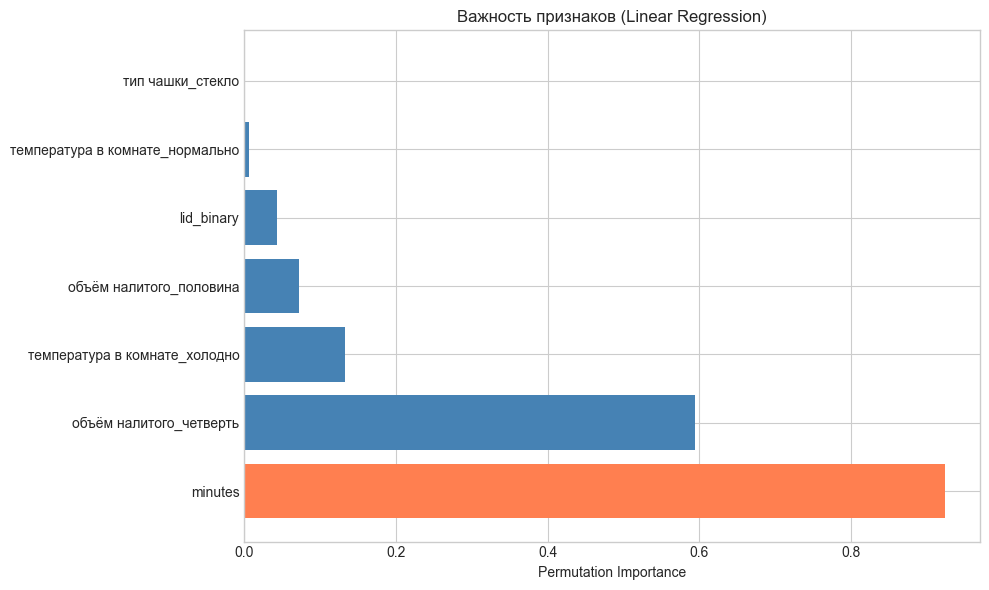

In [29]:
perm_importance = permutation_importance(best_reg_model, X_test_reg, y_test_reg, n_repeats=10, random_state=42)
perm_results = pd.DataFrame({
    'Feature': X_test_reg.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print(perm_results.to_string(index=False))

plt.figure(figsize=(10, 6))
colors_imp = ['coral' if i == 0 else 'steelblue' for i in range(len(perm_results[:8]))]
plt.barh(perm_results['Feature'][:8], perm_results['Importance'][:8], color=colors_imp)
plt.xlabel('Permutation Importance')
plt.title(f'Важность признаков ({best_model_name})')
plt.tight_layout()
plt.show()

# Итоги 

In [30]:
print(f"""
 Результаты

 Данные:
   - Всего записей: {len(df)}
   - Керамика: {len(df) - df['тип чашки_стекло'].sum()} записей, средняя T = {df[df['тип чашки_стекло'] == 0][target].mean():.1f}°C
   - Стекло: {int(df['тип чашки_стекло'].sum())} записей, средняя T = {df[df['тип чашки_стекло'] == 1][target].mean():.1f}°C

 Поиск выбросов (IQR):
   - Нижняя граница: {lower_bound:.1f}°C
   - Верхняя граница: {upper_bound:.1f}°C
   - Количество выбросов: {len(outliers_iqr)} из {len(y)} ({100 * len(outliers_iqr) / len(y):.1f}%)
   - Результат: {' Выбросов нет' if len(outliers_iqr) == 0 else f' Найдено {len(outliers_iqr)} выбросов'}

 k-fold кросс-валидация (регрессия, k=5):
   - Лучшая модель: {best_model_name}
   - R² = {cv_results_df.iloc[0]['R²']:.3f}
   - MAE = {cv_results_df.iloc[0]['MAE']:.1f}°C

 Калибровка (Isotonic Regression):
   - Без калибровки: R² = {r2_raw:.3f}, MAE = {mae_raw:.1f}°C
   - С калибровкой:  R² = {r2_cal:.3f}, MAE = {mae_cal:.1f}°C
   - Результат: {' Улучшение' if r2_cal > r2_raw else ' Калибровка не потребовалась'}

 Диагностика:
   - Нормальность остатков: {' да' if shapiro_p > 0.05 else ' нет'}
   - Ключевые признаки: {perm_results.iloc[0]['Feature']}, {perm_results.iloc[1]['Feature']}
""")


 Результаты

 Данные:
   - Всего записей: 100
   - Керамика: 49 записей, средняя T = 62.4°C
   - Стекло: 51 записей, средняя T = 63.7°C

 Поиск выбросов (IQR):
   - Нижняя граница: 27.0°C
   - Верхняя граница: 101.2°C
   - Количество выбросов: 0 из 100 (0.0%)
   - Результат:  Выбросов нет

 k-fold кросс-валидация (регрессия, k=5):
   - Лучшая модель: Linear Regression
   - R² = 0.867
   - MAE = 3.2°C

 Калибровка (Isotonic Regression):
   - Без калибровки: R² = 0.852, MAE = 3.5°C
   - С калибровкой:  R² = 0.857, MAE = 3.8°C
   - Результат:  Улучшение

 Диагностика:
   - Нормальность остатков:  да
   - Ключевые признаки: minutes, объём налитого_четверть

